# Description

Ze względu na ograniczone zasoby sprzętowe zdecydowałem się na dokładniejszą analize dostępnych w projekcie modeli. W tym celu wykorzystałem 20 zdjęć: 10 prawdziwych zdjęć ludzi oraz 10 zdjęć wygenerowanych przez ai z naciskiem na "deepfake"

# Code

In [9]:
import onnxruntime as ort
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import onnx

In [ ]:
def validation(model_path, input_size, batch_size = 32):
    data_dir="Dodatkowe_dane_walidacyjne"

    transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])


    dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    num_classes = len(dataset.classes)


    session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name


    all_labels = []
    all_preds = []

    for images, labels in dataloader:
        images_np = images.numpy()
        outputs = session.run([output_name], {input_name: images_np})[0]
        preds = np.argmax(outputs, axis=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)


    average_type = 'binary' if num_classes == 2 else 'macro'
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average=average_type)
    recall = recall_score(all_labels, all_preds, average=average_type)
    f1 = f1_score(all_labels, all_preds, average=average_type)
    cm = confusion_matrix(all_labels, all_preds)

    print("\n=== Statistics ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}\n")

    print("=== Confusion Matrix ===")
    print(cm)
    if num_classes == 2:
        tn, fp, fn, tp = cm.ravel()
        print(f"True Negative:  {tn}")
        print(f"False Positive: {fp}")
        print(f"False Negative: {fn}")
        print(f"True Positive:  {tp}\n")

    print("=== Report ===")
    print(classification_report(all_labels, all_preds, target_names=dataset.classes))
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=dataset.classes, yticklabels=dataset.classes)
    plt.xlabel('Predicted class')
    plt.ylabel('Real class')
    plt.title(f'Confusion Matrix - ONNX model')
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

# Validation of baseline model

In [10]:
model = onnx.load("baseline_model.onnx")
input_tensor = model.graph.input[0]
input_shape = [dim.dim_value for dim in input_tensor.type.tensor_type.shape.dim]

print("Wejście modelu:", input_tensor.name)
print("Kształt wejścia:", input_shape)

Wejście modelu: x
Kształt wejścia: [1, 3, 64, 64]



=== Statistics ===
Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000

=== Confusion Matrix ===
[[10  0]
 [10  0]]
True Negative:  10
False Positive: 0
False Negative: 10
True Positive:  0

=== Report ===
              precision    recall  f1-score   support

          ai       0.50      1.00      0.67        10
        real       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificat

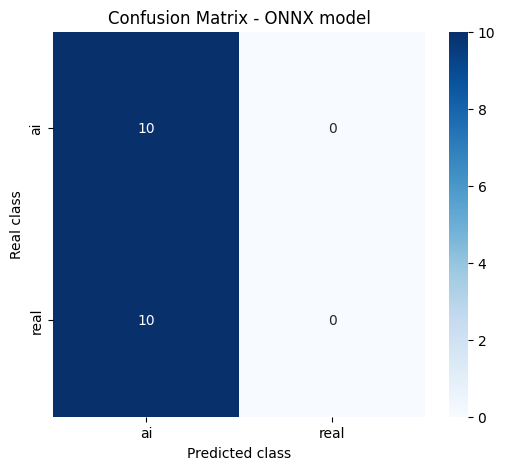

{'accuracy': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'confusion_matrix': array([[10,  0],
        [10,  0]], dtype=int64)}

In [13]:
validation("baseline_model.onnx", input_size=64, batch_size=1)

# Validation of EfficientNetB3 model


=== Statistics ===
Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000

=== Confusion Matrix ===
[[10  0]
 [10  0]]
True Negative:  10
False Positive: 0
False Negative: 10
True Positive:  0

=== Report ===
              precision    recall  f1-score   support

          ai       0.50      1.00      0.67        10
        real       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificat

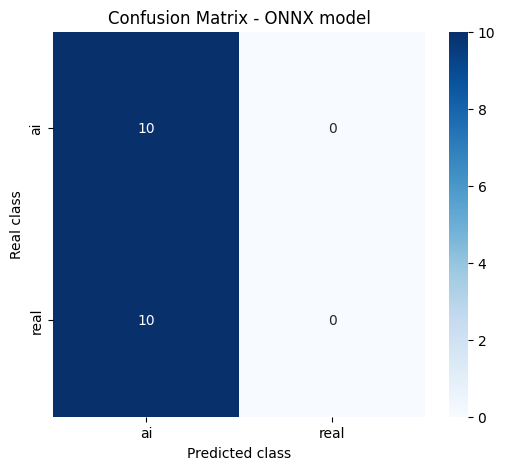

{'accuracy': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'confusion_matrix': array([[10,  0],
        [10,  0]], dtype=int64)}

In [14]:
validation("model_efficientnet_b3.onnx", input_size=300)

# Validation of Resnet50 model

C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Komputer\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificat


=== Statistics ===
Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000

=== Confusion Matrix ===
[[10  0]
 [10  0]]
True Negative:  10
False Positive: 0
False Negative: 10
True Positive:  0

=== Report ===
              precision    recall  f1-score   support

          ai       0.50      1.00      0.67        10
        real       0.00      0.00      0.00        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20



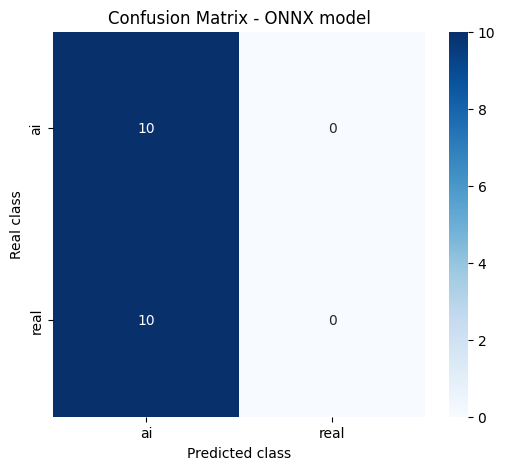

{'accuracy': 0.5,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'confusion_matrix': array([[10,  0],
        [10,  0]], dtype=int64)}

In [4]:
validation("model_resnet_50.onnx", input_size=224)

# Validaton of Vision_Transformer_B16 model


=== Statistics ===
Accuracy:  0.6000
Precision: 1.0000
Recall:    0.2000
F1-score:  0.3333

=== Confusion Matrix ===
[[10  0]
 [ 8  2]]
True Negative:  10
False Positive: 0
False Negative: 8
True Positive:  2

=== Report ===
              precision    recall  f1-score   support

          ai       0.56      1.00      0.71        10
        real       1.00      0.20      0.33        10

    accuracy                           0.60        20
   macro avg       0.78      0.60      0.52        20
weighted avg       0.78      0.60      0.52        20



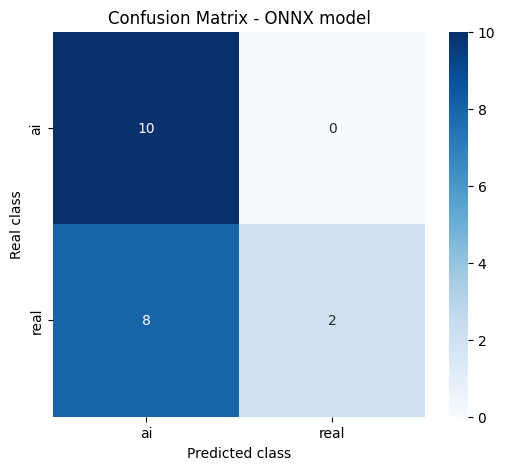

{'accuracy': 0.6,
 'precision': 1.0,
 'recall': 0.2,
 'f1': 0.3333333333333333,
 'confusion_matrix': array([[10,  0],
        [ 8,  2]], dtype=int64)}

In [5]:
validation("Vision_Transformer_B16.onnx", input_size=224)